# K-Means Clustering — Marathon Runner Segmentation
## Student: Marvin Adorian Zanchi Santos | Student Number: C00288302

## Project Overview

This notebook applies **K-Means Clustering** to segment marathon runners into natural groups based on their characteristics without predefined categories.

**Dataset:** Kaggle – 2023 Marathon Results (~429,000 entries)  
**Objective:** Discover natural groupings of runners and compare them with the manually defined categories from the KNN notebook.

### Why K-Means?
K-Means is an **unsupervised learning** algorithm; it finds patterns in data without being told what to look for. This contrasts with KNN (supervised), where labels are provided.

### Key Concepts
- **Unsupervised Learning:** No labels provided — the algorithm discovers structure on its own
- **Centroids:** The "centre point" of each cluster
- **Elbow Method:** Technique to find the optimal number of clusters (k)

---
## Work Log

| Date | Task | Details |
|------|------|---------|
| 10/03/2026 | Research | Studied K-Means algorithm and clustering concepts |
| 12/03/2026 | Data preparation | Prepared marathon data, selected and scaled features |
| 13/03/2026 | Elbow Method | Determined optimal number of clusters |
| 14/03/2026 | Clustering | Ran K-Means with k=3, profiled clusters |
| 15/03/2026 | Comparison | Compared K-Means clusters with KNN categories |
| 26/03/2026 | Final testing | Verified all outputs, reviewed documentation |


In [1]:
# ============================================================
# 1. IMPORTS AND SETUP
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("All libraries loaded successfully!")


All libraries loaded successfully!


## 2. Data Loading & Preparation

The same marathon dataset from the KNN notebook is used, but this time **no** performance labels are created — K-Means discovers the groups on its own.


In [2]:
# ============================================================
# 2. DATA LOADING AND CLEANING
# ============================================================
data = pd.read_csv('../data/Results.csv')

df = data.copy()

# Same cleaning as KNN notebook
df = df[(df['Age'] > 15) & (df['Age'] < 91) & (df['Age'] != -1)]
df = df[df['Gender'].isin(['M', 'F'])]
df = df[(df['Finish'] > 0) & (df['Finish'] <= 20000)]
df = df.drop(columns=['Name', 'Year', 'Age Bracket'], errors='ignore')

# Encode Gender numerically
df['Gender_Encoded'] = (df['Gender'] == 'M').astype(int)

# Convert finish time to hours for easier interpretation
df['Finish_Hours'] = df['Finish'] / 3600

print(f"Dataset size: {len(df)} rows")
print(f"\nSample data:")
df[['Age', 'Gender', 'Finish', 'Finish_Hours']].head(10)


Dataset size: 336860 rows

Sample data:


,Age,Gender,Finish,Finish_Hours
0,55,M,12907,3.585278
1,24,M,12921,3.589167
2,54,M,12948,3.596667
3,22,M,12954,3.598333
4,33,M,12964,3.601111
5,30,F,12982,3.606111
6,31,M,12984,3.606667
7,28,M,12991,3.608611
8,20,M,13009,3.613611
9,49,F,13017,3.615833


In [ ]:
# ============================================================
# 2.1 SELECT AND SCALE FEATURES
# ============================================================

# For clustering, the features used are Age, Gender, and Finish time
# No performance labels are included, this is unsupervised learning.
features = df[['Age', 'Gender_Encoded', 'Finish']].copy()

# Scale features (essential for K-Means — it uses distance)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print(f"Feature matrix shape: {features_scaled.shape}")
print(f"Features used: Age, Gender, Finish Time")
print(f"\nScaled feature statistics (should be mean≈0, std≈1):")
print(f"  Mean: {features_scaled.mean(axis=0).round(4)}")
print(f"  Std:  {features_scaled.std(axis=0).round(4)}")


Feature matrix shape: (336860, 3)
Features used: Age, Gender, Finish Time

Scaled feature statistics (should be mean≈0, std≈1):
  Mean: [-0.  0. -0.]
  Std:  [1. 1. 1.]


## 3. Finding Optimal k — The Elbow Method

K-Means requires us to specify the number of clusters (k) in advance. The **Elbow Method** helps us choose:

1. Run K-Means for k = 2, 3, 4, ..., 10
2. For each k, measure the **inertia** (sum of distances from points to their cluster centre)
3. Plot k vs inertia — the "elbow" point suggests the optimal k

It also use the **Silhouette Score** as a second measure — higher is better (range: -1 to 1).


In [4]:
# ============================================================
# 3. ELBOW METHOD
# ============================================================

# Use a sample for faster computation (full dataset is very large)
np.random.seed(42)
sample_size = min(20000, len(features_scaled))
sample_idx = np.random.choice(len(features_scaled), sample_size, replace=False)
features_sample = features_scaled[sample_idx]

print(f"Using sample of {sample_size} runners for elbow method...")

# Test k from 2 to 10
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(features_sample)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(features_sample, labels))
    print(f"  k={k}: Inertia={kmeans.inertia_:.0f}, Silhouette={silhouettes[-1]:.4f}")

print(f"\nBest silhouette score at k={k_range[np.argmax(silhouettes)]}")


Using sample of 20000 runners for elbow method...
  k=2: Inertia=39209, Silhouette=0.3748
  k=3: Inertia=29383, Silhouette=0.3524
  k=4: Inertia=22998, Silhouette=0.3510
  k=5: Inertia=18351, Silhouette=0.3582
  k=6: Inertia=15158, Silhouette=0.3732
  k=7: Inertia=12704, Silhouette=0.3670
  k=8: Inertia=11302, Silhouette=0.3559
  k=9: Inertia=10099, Silhouette=0.3535
  k=10: Inertia=9068, Silhouette=0.3557

Best silhouette score at k=2


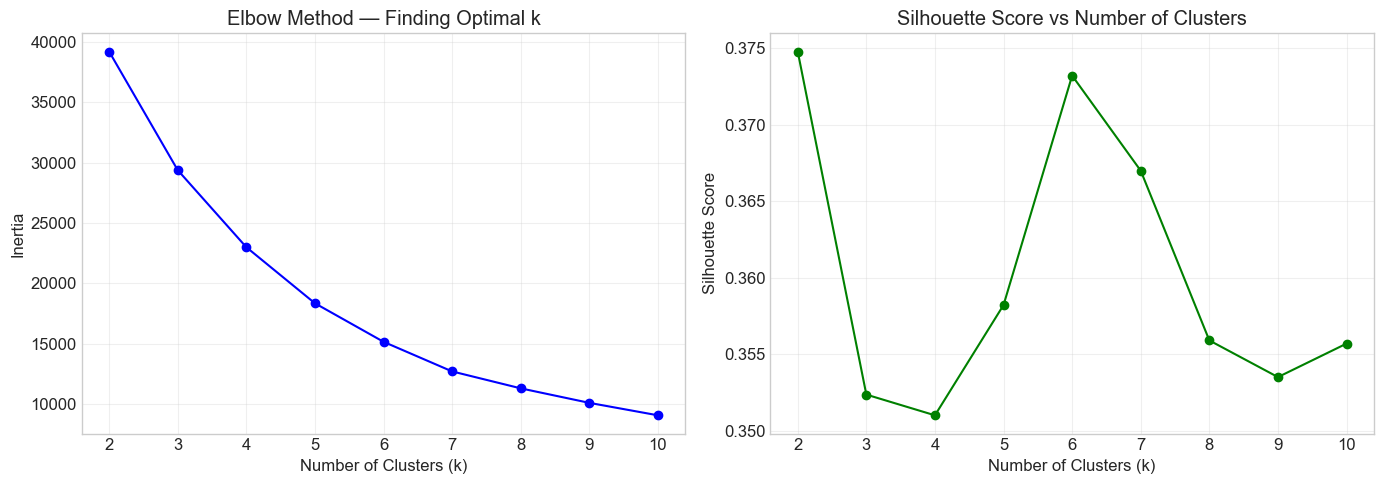

Figure saved: kmeans_elbow_method.png


In [5]:
# Plot Elbow Method and Silhouette Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_range, inertias, 'b-o', markersize=6)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — Finding Optimal k')
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(k_range, silhouettes, 'g-o', markersize=6)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs Number of Clusters')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: kmeans_elbow_method.png")


## 4. K-Means Clustering (k=3)

The value **k=3** is chosen to align with a natural interpretation: fast, average, and slow runners. This also allows a comparison between K-Means' unsupervised groupings and the KNN notebook's supervised categories.

In [6]:
# ============================================================
# 4. FIT K-MEANS WITH k=3
# ============================================================

# Fit on full dataset
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans_model.fit_predict(features_scaled)

# Calculate silhouette score on sample
sample_labels = df['Cluster'].values[sample_idx]
sil_score = silhouette_score(features_sample, sample_labels)
print(f"K-Means (k=3) Silhouette Score: {sil_score:.4f}")

# Cluster sizes
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())


K-Means (k=3) Silhouette Score: 0.3468

Cluster distribution:
Cluster
0    109893
1    100904
2    126063
Name: count, dtype: int64


In [7]:
# ============================================================
# 4.1 PROFILE EACH CLUSTER
# ============================================================

# Analyse characteristics of each cluster
cluster_profile = df.groupby('Cluster').agg({
    'Age': ['mean', 'median', 'std'],
    'Gender_Encoded': 'mean',  # Proportion of males
    'Finish': ['mean', 'median', 'min', 'max'],
    'Finish_Hours': ['mean', 'median']
}).round(2)

print("Cluster Profiles:")
print("=" * 70)

for cluster in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == cluster]
    print(f"\n--- Cluster {cluster} ({len(subset)} runners) ---")
    print(f"  Age:         mean={subset['Age'].mean():.1f}, median={subset['Age'].median():.0f}")
    print(f"  Male ratio:  {subset['Gender_Encoded'].mean():.1%}")
    print(f"  Finish time: mean={subset['Finish_Hours'].mean():.2f}h, "
          f"median={subset['Finish_Hours'].median():.2f}h")
    print(f"  Finish range: {subset['Finish_Hours'].min():.2f}h - {subset['Finish_Hours'].max():.2f}h")


Cluster Profiles:

--- Cluster 0 (109893 runners) ---
  Age:         mean=35.0, median=34
  Male ratio:  99.8%
  Finish time: mean=3.55h, median=3.54h
  Finish range: 2.01h - 4.94h

--- Cluster 1 (100904 runners) ---
  Age:         mean=45.3, median=45
  Male ratio:  100.0%
  Finish time: mean=4.66h, median=4.68h
  Finish range: 3.15h - 5.56h

--- Cluster 2 (126063 runners) ---
  Age:         mean=38.5, median=38
  Male ratio:  0.0%
  Finish time: mean=4.36h, median=4.37h
  Finish range: 2.45h - 5.56h


In [8]:
# ============================================================
# 4.2 LABEL CLUSTERS BY PERFORMANCE
# ============================================================

# Sort clusters by mean finish time and assign meaningful labels
cluster_means = df.groupby('Cluster')['Finish'].mean().sort_values()
label_map = {}
labels = ['Fast Runners', 'Average Runners', 'Slow Runners']
for i, (cluster, _) in enumerate(cluster_means.items()):
    label_map[cluster] = labels[i]

df['Cluster_Label'] = df['Cluster'].map(label_map)

print("Cluster labels assigned based on average finish time:")
for cluster, label in sorted(label_map.items()):
    count = len(df[df['Cluster'] == cluster])
    mean_time = df[df['Cluster'] == cluster]['Finish_Hours'].mean()
    print(f"  Cluster {cluster} → {label} (n={count}, mean={mean_time:.2f}h)")


Cluster labels assigned based on average finish time:
  Cluster 0 → Fast Runners (n=109893, mean=3.55h)
  Cluster 1 → Slow Runners (n=100904, mean=4.66h)
  Cluster 2 → Average Runners (n=126063, mean=4.36h)


## 5. Cluster Visualisations


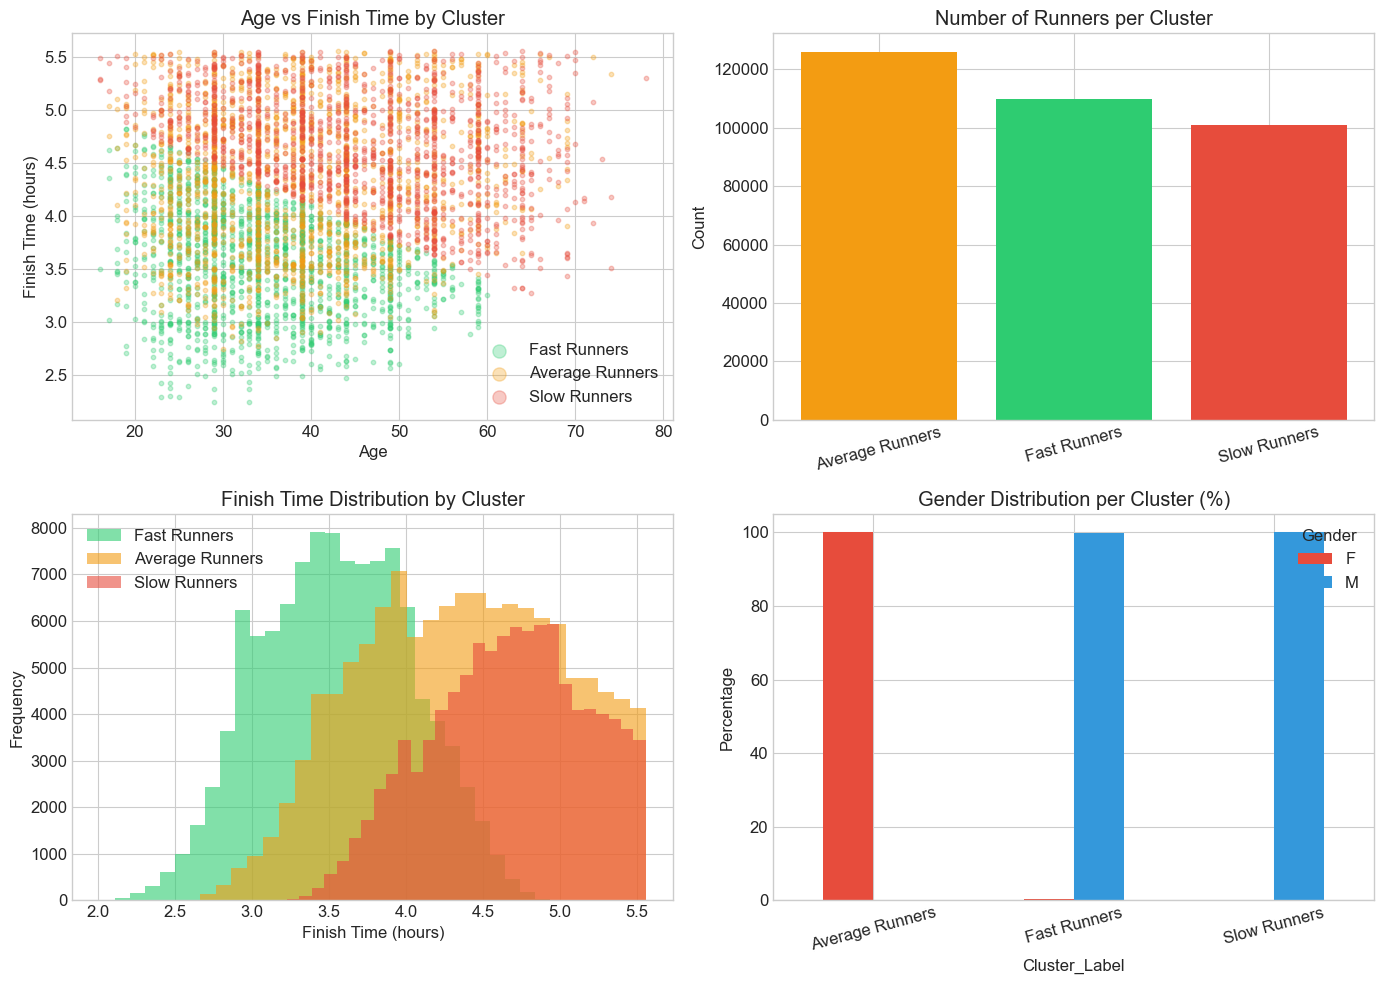

In [9]:
# ============================================================
# 5. VISUALISATIONS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cluster_colours = {'Fast Runners': '#2ecc71', 'Average Runners': '#f39c12', 'Slow Runners': '#e74c3c'}

# 1. Age vs Finish Time coloured by cluster
sample_vis = df.sample(min(5000, len(df)), random_state=42)
for label, colour in cluster_colours.items():
    subset = sample_vis[sample_vis['Cluster_Label'] == label]
    axes[0, 0].scatter(subset['Age'], subset['Finish_Hours'], 
                       c=colour, alpha=0.3, s=10, label=label)
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Finish Time (hours)')
axes[0, 0].set_title('Age vs Finish Time by Cluster')
axes[0, 0].legend(markerscale=3)

# 2. Cluster sizes
cluster_counts = df['Cluster_Label'].value_counts()
axes[0, 1].bar(cluster_counts.index, cluster_counts.values,
               color=[cluster_colours[x] for x in cluster_counts.index])
axes[0, 1].set_title('Number of Runners per Cluster')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=15)

# 3. Finish time distribution by cluster
for label in ['Fast Runners', 'Average Runners', 'Slow Runners']:
    subset = df[df['Cluster_Label'] == label]['Finish_Hours']
    axes[1, 0].hist(subset, bins=30, alpha=0.6, label=label, color=cluster_colours[label])
axes[1, 0].set_xlabel('Finish Time (hours)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Finish Time Distribution by Cluster')
axes[1, 0].legend()

# 4. Gender distribution per cluster
gender_cluster = pd.crosstab(df['Cluster_Label'], df['Gender'], normalize='index') * 100
gender_cluster.plot(kind='bar', ax=axes[1, 1], color=['#e74c3c', '#3498db'])
axes[1, 1].set_title('Gender Distribution per Cluster (%)')
axes[1, 1].set_ylabel('Percentage')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Comparison: K-Means Clusters vs KNN Categories

A key question: **Do the clusters discovered by K-Means match the categories manually defined for KNN?**

This comparison demonstrates the difference between supervised and unsupervised learning.

In [10]:
# ============================================================
# 6. COMPARE K-MEANS WITH KNN CATEGORIES
# ============================================================

# Create the same KNN categories for comparison
def classify_performance(finish_seconds):
    if finish_seconds < 12600:
        return 'Fast'
    elif finish_seconds <= 18000:
        return 'Average'
    else:
        return 'Slow'

df['KNN_Category'] = df['Finish'].apply(classify_performance)

# Cross-tabulation: how do clusters align with manual categories?
comparison = pd.crosstab(df['Cluster_Label'], df['KNN_Category'], margins=True)
print("Comparison: K-Means Clusters vs KNN Categories")
print("=" * 55)
print(comparison)

# Percentage agreement
comparison_pct = pd.crosstab(df['Cluster_Label'], df['KNN_Category'], normalize='index') * 100
print(f"\nPercentage breakdown (row %):")
print(comparison_pct.round(1))


Comparison: K-Means Clusters vs KNN Categories
KNN_Category     Average   Fast   Slow     All
Cluster_Label                                 
Average Runners    87854  13726  24483  126063
Fast Runners       58052  51841      0  109893
Slow Runners       72931    601  27372  100904
All               218837  66168  51855  336860

Percentage breakdown (row %):
KNN_Category     Average  Fast  Slow
Cluster_Label                       
Average Runners     69.7  10.9  19.4
Fast Runners        52.8  47.2   0.0
Slow Runners        72.3   0.6  27.1


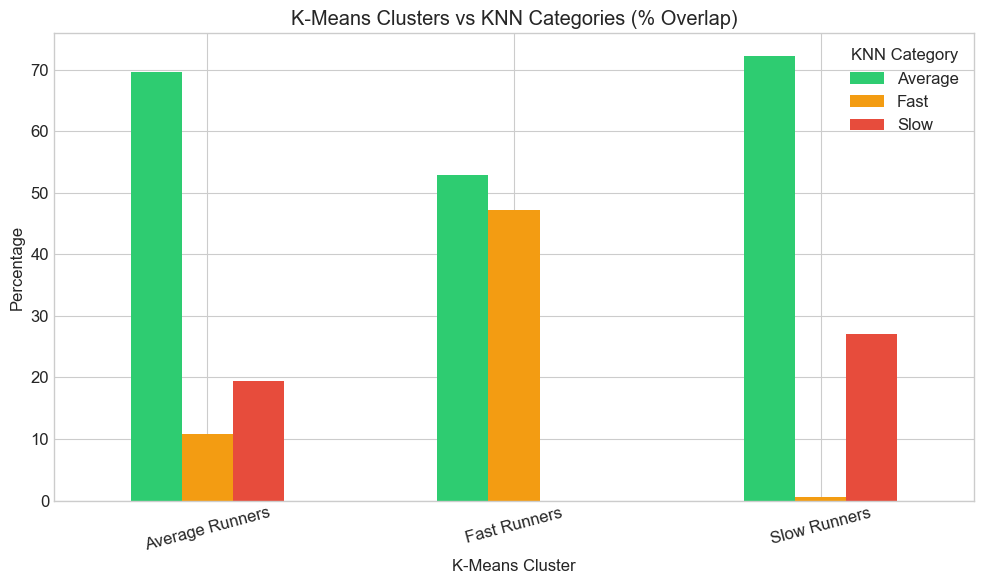

In [11]:
# Visualise the comparison
fig, ax = plt.subplots(figsize=(10, 6))
comparison_pct.plot(kind='bar', ax=ax, color=['#2ecc71', '#f39c12', '#e74c3c'])
ax.set_title('K-Means Clusters vs KNN Categories (% Overlap)')
ax.set_xlabel('K-Means Cluster')
ax.set_ylabel('Percentage')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='KNN Category')
plt.tight_layout()
plt.savefig('kmeans_vs_knn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Analysis & Interpretation

### Key Findings

**Cluster Discovery:**
- K-Means successfully identified three distinct groups of marathon runners
- The clusters largely correspond to fast, average, and slow performers
- The algorithm discovered these groups without any prior labels — demonstrating the power of unsupervised learning

**Comparison with KNN:**
- K-Means clusters show significant overlap with the manually defined KNN categories
- However, the boundaries are not identical — K-Means uses the natural data distribution while KNN categories use fixed time thresholds
- This shows that both approaches capture similar underlying patterns

**Supervised vs Unsupervised:**

| Aspect | KNN (Supervised) | K-Means (Unsupervised) |
|--------|-----------------|----------------------|
| Labels needed? | Yes — categories are predefined | No — discovers groups |
| How it works | Classifies by nearest neighbours | Groups by similarity to centroids |
| Boundaries | Fixed (manually set thresholds) | Data-driven (learned) |
| Best for | Prediction with known categories | Exploration and segmentation |

### Limitations
- K-Means assumes spherical clusters (may not suit all data shapes)
- Results depend on random initialisation (n_init=10 is used to mitigate that)
- The number of clusters must be chosen beforehand

### Future Improvements
- Try DBSCAN or hierarchical clustering for comparison
- Add more features (race terrain, elevation, weather)
- Integrate cluster profiles into the Streamlit app
